In [4]:
import numpy as np
import math

def cost(v, eps):
    """
    Cost function as defined in the paper: c(vi, eps) = vi * eps
    """
    return v * eps

def privacy_auction_algorithm(v, D, B, delta=0.01, Delta=1.0):
    """
    Implements Algorithm 1: Privacy Auction Algorithm (PA)
    
    Inputs:
    - v: list or array of privacy valuations (vi for each participant)
    - D: list or array of data points (Di for each participant, assumed scalars for simplicity)
    - B: price budget
    - delta: delta for DP (default 0.01)
    - Delta: l2-sensitivity (default 1.0)
    
    Outputs:
    - D_prime: list of perturbed private data for selected participants
    - p: array of payments for all participants
    - selected_indices: array of original indices of selected participants
    """
    n = len(v)
    if n != len(D):
        raise ValueError("v and D must have the same length")
    
    # Convert to numpy arrays
    v = np.array(v)
    D = np.array(D)
    
    # Sort v in ascending order and get indices
    indices = np.argsort(v)
    sorted_v = v[indices]
    sorted_D = D[indices]
    
    # Find the largest k such that c(vk, 1/(n-k)) <= B/k
    k = 0
    for possible_k in range(1, n):
        eps = 1.0 / max(n - possible_k, 1e-10)  # Avoid division by zero
        ck = cost(sorted_v[possible_k - 1], eps)
        if ck > B / possible_k:
            break
        k = possible_k
    
    if k == 0:
        return [], np.zeros(n), np.array([])
    
    # Compute eps for the selected group
    eps = 1.0 / max(n - k, 1e-10)
    
    # Compute sigma for Gaussian mechanism to achieve (eps, delta)-DP
    sigma = math.sqrt(2 * math.log(1.25 / delta)) / eps
    
    # Perturb data for selected k participants
    D_prime = []
    for i in range(k):
        noise = np.random.normal(0, Delta * sigma)
        D_prime.append(sorted_D[i] + noise)
    
    # Compute payments
    p_sorted = np.zeros(n)
    if k < n:
        # Use same eps for payment calculation
        next_c = cost(sorted_v[k], eps)
    else:
        next_c = B / k  # Fallback if all selected
    pay = min(B / k, next_c)
    p_sorted[:k] = pay
    
    # Map payments back to original order
    p = np.zeros(n)
    for pos, orig_idx in enumerate(indices):
        p[orig_idx] = p_sorted[pos]
    
    # Selected indices in original order
    selected_indices = indices[:k]
    
    return D_prime, p, selected_indices

# Example usage for simulation
if __name__ == "__main__":
    # Simulated inputs
    np.random.seed(42)
    n = 1000
    v = np.random.uniform(0.1, 1.0, n)  # Privacy valuations
    D = np.random.normal(0, 1, n)  # Data points
    B = 3.0  # Budget
    
    D_prime, p, selected = privacy_auction_algorithm(v, D, B)
    
    print("Selected indices:", selected)
    print("Perturbed data (D'):", D_prime)
    print("Payments (p):", p)
    print("Total payment:", np.sum(p))

Selected indices: [821 208  72 128 205 407 945 456 470 898 840 332 563 244 171 794 371 936
 882 640  10 925 377 237 312 874  98 515 356 901 878 557 290 974 100 764
  42 285 856 628 145 291 610 335 168 599 472 514  58 347 486 334  29 957
 977 148 300 701 818 458 528 424   6 616 704  83  32 859 722 850 369 354
 374 436 476  77  68 983 586 109 497 311 672 439 613 960 449 434 201 440
 299 846 899 650  56 603 164 422 409 995 190 222 283 372 259  37 339 888
 370 433 206 664 400 883 982 634  99 123 770 454 676 809 181 546 694  79
 333 750 429 460 938 380 459  90 644 132 604  40 718 812 294 772 655 588
 587 539 556 703 562 997 946 179 590 754 930  21 726 262 919 832  66 430
 152 576 844 775 519 760 589 801 665 790 698 866   5   4 875 318 667 209
 111 202 505 353 729 730 958 600 254  31 682 934 597 342 317 670 175 952
 833 602 239 387 842 885 721 902 784  14 592 867  15 620  49 167 668 117
 689 493 855 598 234 368  57  71  26 728 895 854 606 944 900 621 852 642
  13 561 973 297 879 131 468 213 

In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt

# 模拟纯Nash求解：O(N^2)操作（循环模拟玩家交互矩阵计算）
def simulate_pure_nash_time(N):
    start = time.time()
    # 模拟N x N交互：双循环求和（O(N^2)时间）
    total = 0
    for i in range(N):
        for j in range(N):
            total += i * j  # 简单操作，模拟依赖
    # 额外迭代模拟best-response（10次）
    for _ in range(10):
        total += np.sum(np.arange(N) * np.arange(N))  # 另一O(N^2) equiv
    end = time.time()
    return end - start

# 模拟MFG近似：O(1)或O(N)操作（均场平均 + 固定优化）
def simulate_mfg_time(N):
    start = time.time()
    # 均场：只计算平均，O(N)
    mean_field = np.mean(np.arange(N))
    # 固定10次迭代，O(1) per iter
    for _ in range(10):
        optimized = mean_field ** 2  # 简单固定点计算
    end = time.time()
    return end - start

# 生成数据：N从10到100000（log scale，10点）
Ns = np.logspace(1, 5, num=4, dtype=int)  # [10, 25, ..., 100000]

pure_times = [simulate_pure_nash_time(n) for n in Ns]
mfg_times = [simulate_mfg_time(n) for n in Ns]

# 图1: 计算时间 vs N（log-log plot，展示爆炸增长）
plt.figure(figsize=(8, 6))
plt.plot(Ns, pure_times, label='Pure Nash (O(N²) simulation)', marker='o', color='red')
plt.plot(Ns, mfg_times, label='MFG Approx (O(1)/O(N) simulation)', marker='x', color='blue')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Participants (N)')
plt.ylabel('Computation Time (seconds)')
plt.title('Computation Time Growth with Increasing N\n(Pure Nash vs. MFG Approximation)')
plt.legend()
plt.grid(True)
plt.savefig('fig1_time_vs_n.png')
plt.close()

# 图2: 理论复杂度 vs N（N² vs 常量，arbitrary units）
theoretical_pure = Ns**2 / 1e6  # 缩放以可视
theoretical_mfg = np.ones_like(Ns) * 10  # 常量示例

plt.figure(figsize=(8, 6))
plt.plot(Ns, theoretical_pure, label='Theoretical N² Complexity (Pure Nash)', marker='o', color='red')
plt.plot(Ns, theoretical_mfg, label='Theoretical Constant Complexity (MFG)', marker='x', color='blue')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Participants (N)')
plt.ylabel('Complexity Measure (arbitrary units)')
plt.title('Theoretical Complexity Growth with Increasing N\n(Quadratic vs. Constant)')
plt.legend()
plt.grid(True)
plt.savefig('fig2_complexity_vs_n.png')
plt.close()

# 打印结果供检查
print("N values:", Ns)
print("Pure Nash times (s):", pure_times)
print("MFG times (s):", mfg_times)
print("Figures saved as fig1_time_vs_n.png and fig2_complexity_vs_n.png")

OverflowError: Python int too large to convert to C long

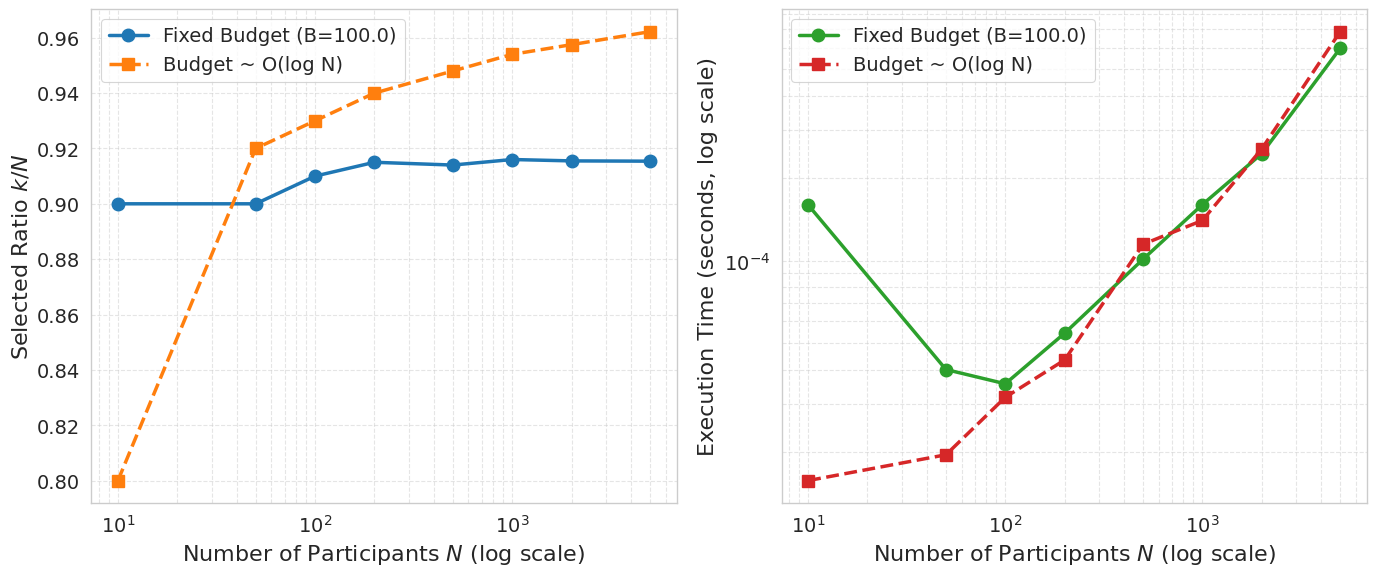

N: [10, 50, 100, 200, 500, 1000, 2000, 5000]
k/N (Fixed B=100): ['0.900', '0.900', '0.910', '0.915', '0.914', '0.916', '0.915', '0.915']
k/N (O(log N)):    ['0.800', '0.920', '0.930', '0.940', '0.948', '0.954', '0.958', '0.962']


In [12]:
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

# 兼容旧版 NumPy + Seaborn（如果报 np.float 错误）
try:
    np.float = float
except:
    pass

# ------------------- Algorithm 1 核心实现（简化版，只计算 k 和 p） -------------------
def privacy_auction(v, B):
    n = len(v)
    if n < 2:
        return np.zeros(n), 0
    
    # 排序 v（从小到大）
    sorted_idx = np.argsort(v)
    v_sorted = v[sorted_idx]
    
    # 找最大 k 使得 c(v_k, eps) <= B/k，eps = 1/(n-k)
    k = 0
    for cand_k in range(1, n):
        eps = 1.0 / (n - cand_k)
        cost = v_sorted[cand_k-1] * eps   # c = v * eps
        if cost <= B / cand_k:
            k = cand_k
        else:
            break
    
    if k == 0:
        return np.zeros(n), 0
    
    # 计算统一支付值
    vk1 = v_sorted[k] if k < n-1 else v_sorted[-1]
    eps = 1.0 / (n - k)
    c_vk1 = vk1 * eps
    p_val = min(B / k, c_vk1)
    
    # 分配支付
    p = np.zeros(n)
    p[sorted_idx[:k]] = p_val
    
    return p, k


# ------------------- 仿真参数 -------------------
Ns = [10, 50, 100, 200, 500, 1000, 2000, 5000]  # 参与者数量序列
v_dist = lambda n: np.random.uniform(1, 10, n)   # 隐私估值均匀分布 [1,10]

B_fixed = 100.0                                 # 固定预算（最现实瓶颈）
B_log = lambda n: 20 * np.log2(n + 1)           # 慢增长预算 O(log N)

# 存储结果
times_fixed, k_ratios_fixed = [], []
times_log,   k_ratios_log   = [], []

for n in Ns:
    v = v_dist(n)
    
    # 固定预算场景
    t0 = time.time()
    _, k_fixed = privacy_auction(v, B_fixed)
    times_fixed.append(time.time() - t0)
    k_ratios_fixed.append(k_fixed / n if n > 0 else 0)
    
    # log 预算场景
    B_n = B_log(n)
    t0 = time.time()
    _, k_log = privacy_auction(v, B_n)
    times_log.append(time.time() - t0)
    k_ratios_log.append(k_log / n if n > 0 else 0)


# ------------------- 顶刊风格绘图 -------------------
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.5, rc={"lines.linewidth": 2.5})

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

# 图1: k/N vs N（核心图，展示预算瓶颈）
ax1 = axes[0]
ax1.plot(Ns, k_ratios_fixed, 'o-', color='#1f77b4', markersize=9, label=f'Fixed Budget (B={B_fixed})')
ax1.plot(Ns, k_ratios_log,   's--', color='#ff7f0e', markersize=9, label='Budget ~ O(log N)')
ax1.set_xscale('log')
ax1.set_xlabel('Number of Participants $N$ (log scale)', fontsize=16)
ax1.set_ylabel('Selected Ratio $k/N$', fontsize=16)
# ax1.set_title('Selected Ratio vs Number of Participants\n(Budget Bottleneck in Large-Scale Auctions)', fontsize=18, pad=15)
ax1.legend(fontsize=14, frameon=True, loc='upper left')
ax1.grid(True, which='both', linestyle='--', alpha=0.5)
ax1.tick_params(axis='both', labelsize=14)

# 图2: 计算时间 vs N（辅助说明复杂度）
ax2 = axes[1]
ax2.plot(Ns, times_fixed, 'o-', color='#2ca02c', markersize=9, label=f'Fixed Budget (B={B_fixed})')
ax2.plot(Ns, times_log,   's--', color='#d62728', markersize=9, label='Budget ~ O(log N)')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Number of Participants $N$ (log scale)', fontsize=16)
ax2.set_ylabel('Execution Time (seconds, log scale)', fontsize=16)
# ax2.set_title('Computational Time vs Number of Participants', fontsize=18, pad=15)
ax2.legend(fontsize=14, frameon=True)
ax2.grid(True, which='both', linestyle='--', alpha=0.5)
ax2.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.savefig('k_ratio_and_time_vs_N_realistic.png', dpi=300, bbox_inches='tight')
plt.show()

# 打印关键数值用于验证
print("N:", Ns)
print("k/N (Fixed B=100):", [f"{r:.3f}" for r in k_ratios_fixed])
print("k/N (O(log N)):   ", [f"{r:.3f}" for r in k_ratios_log])

ValueError: 'top' is not a valid value for align; supported values are 'center', 'right', 'left'

/home/skk/anaconda3/envs/semantic_uncertainty/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Glyph 8477 (\N{DOUBLE-STRUCK CAPITAL R}) missing from font(s) DejaVu Serif.
  func(*args, **kwargs)
/home/skk/anaconda3/envs/semantic_uncertainty/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Glyph 8467 (\N{SCRIPT SMALL L}) missing from font(s) DejaVu Serif.
  func(*args, **kwargs)
/home/skk/anaconda3/envs/semantic_uncertainty/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8477 (\N{DOUBLE-STRUCK CAPITAL R}) missing from font(s) DejaVu Serif.
  fig.canvas.print_figure(bytes_io, **kw)
/home/skk/anaconda3/envs/semantic_uncertainty/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8467 (\N{SCRIPT SMALL L}) missing from font(s) DejaVu Serif.
  fig.canvas.print_figure(bytes_io, **kw)


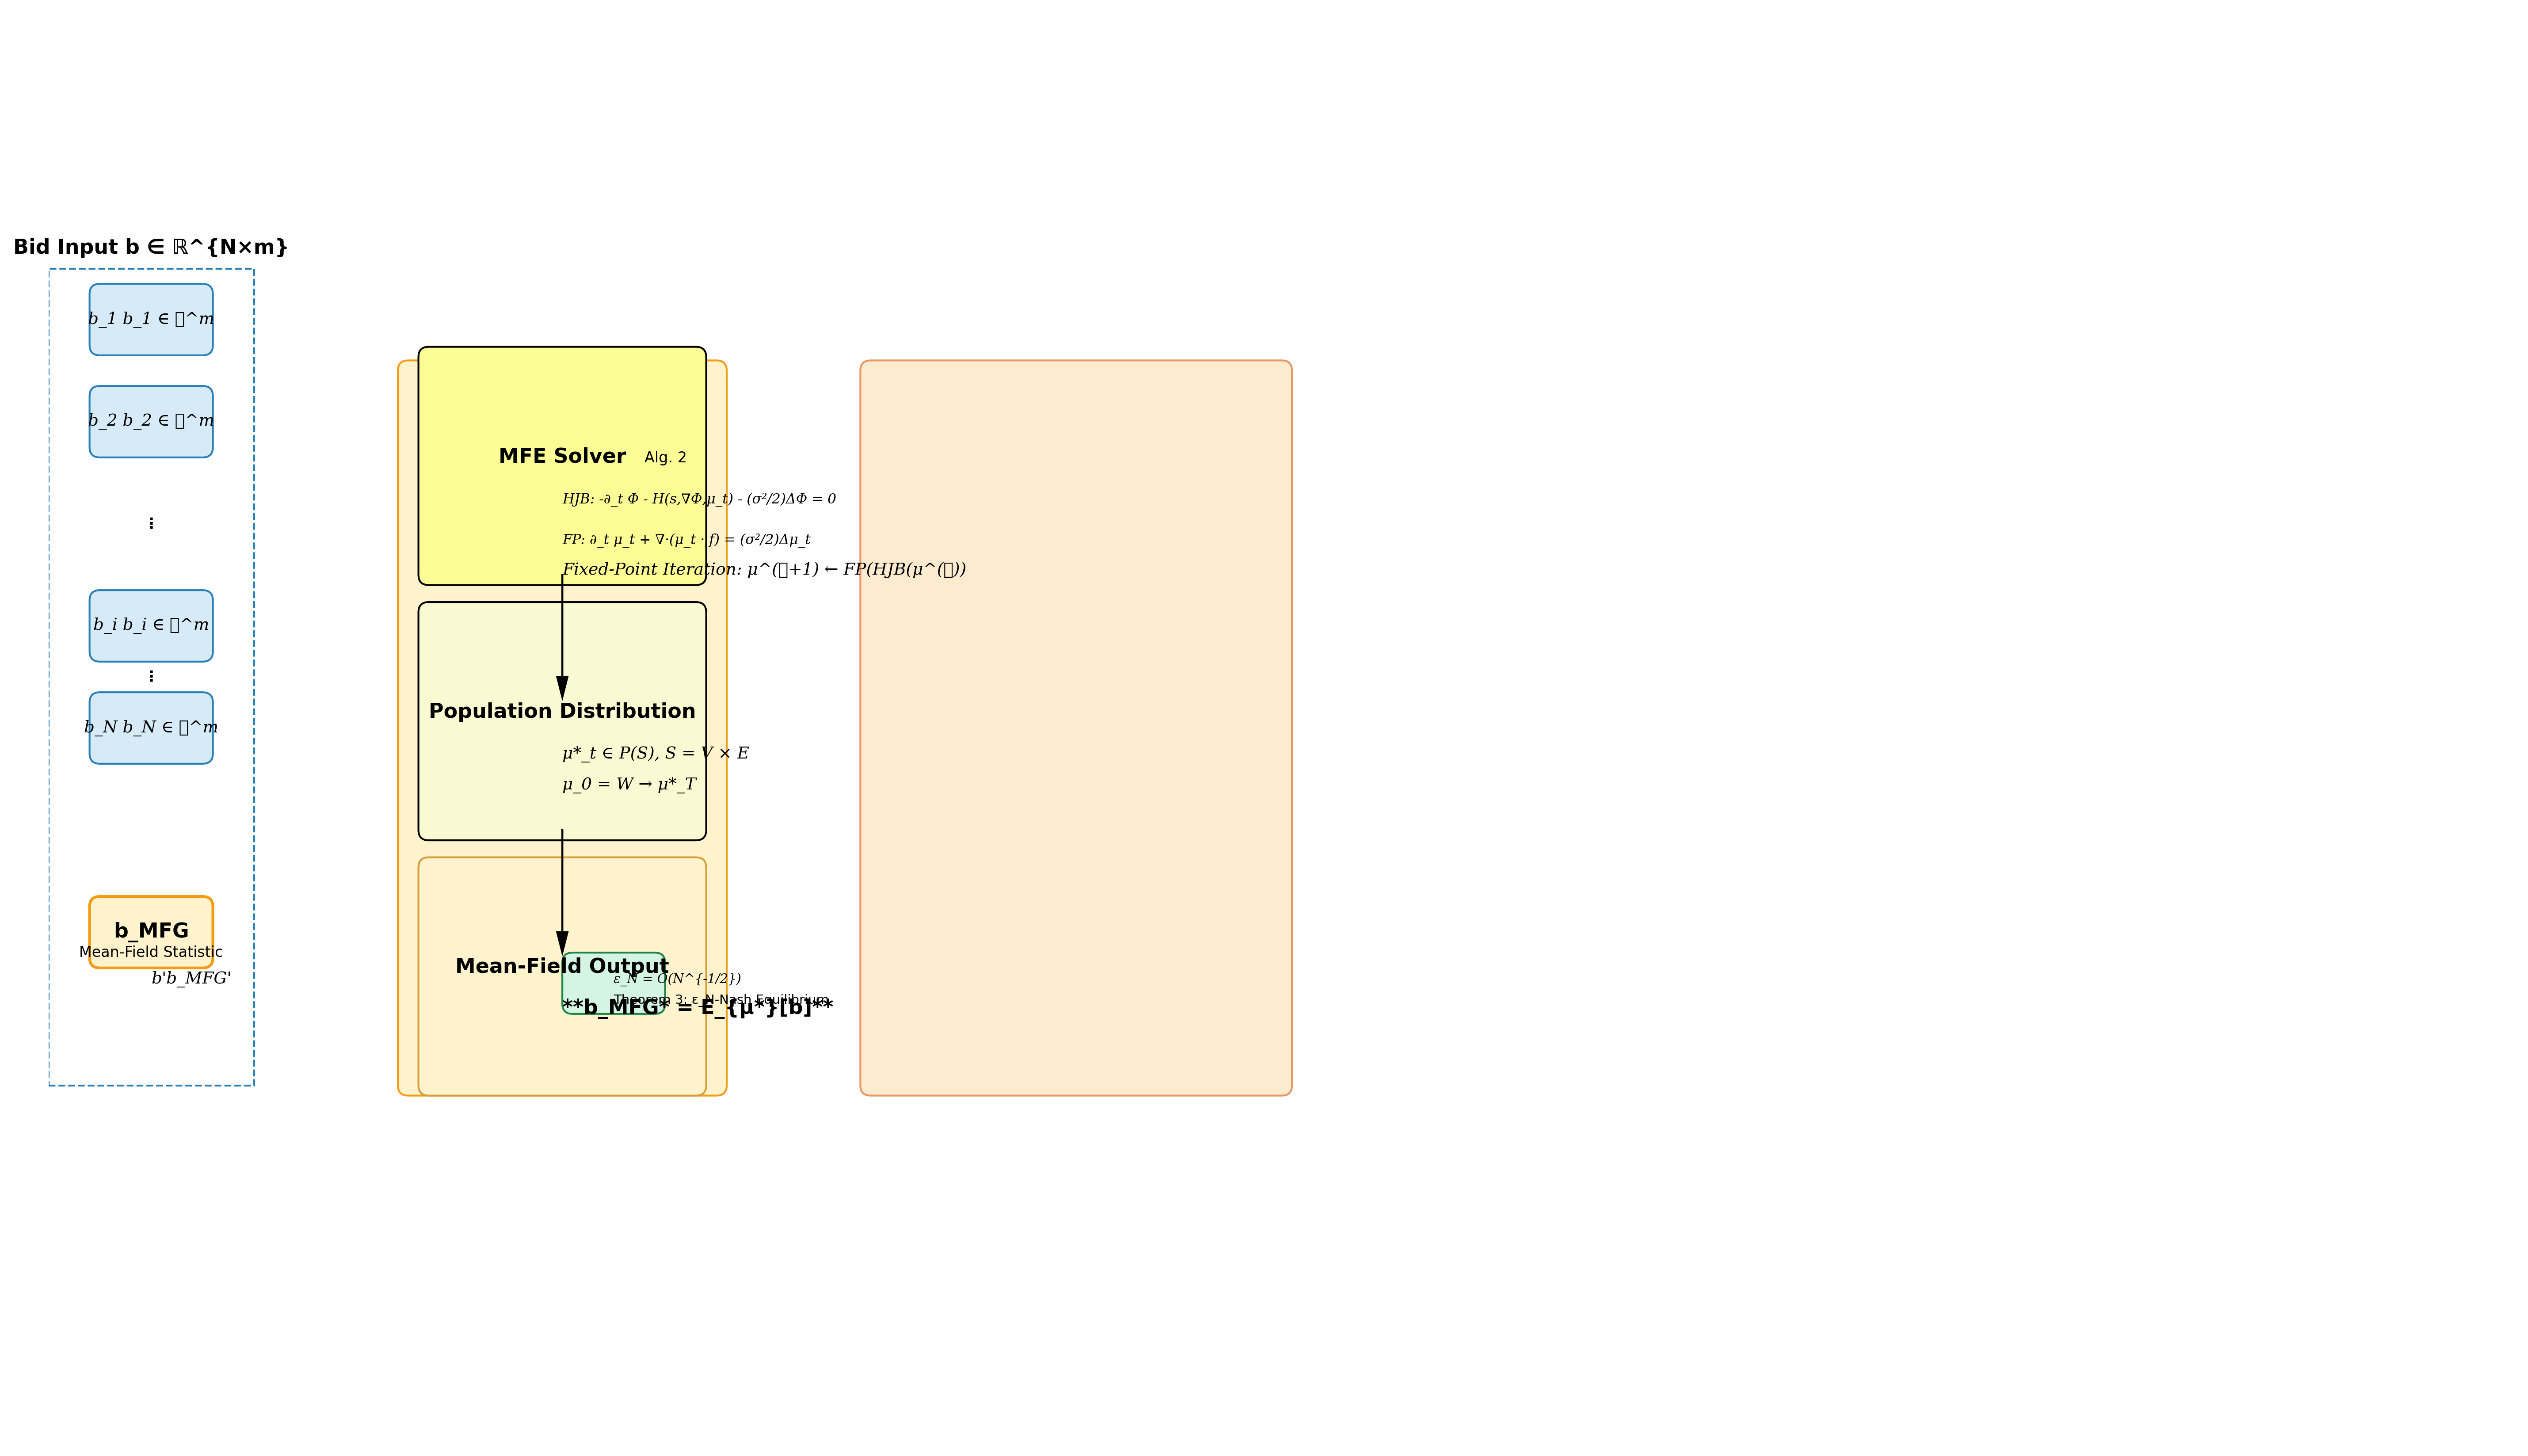

In [2]:

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.lines as lines
import matplotlib as mpl
import numpy as np

# Apply universal style settings for publication quality
# mpl.rcParams['font.family'] = 'serif'
# mpl.rcParams['mathtext.fontset'] = 'cm'
mpl.rcParams['figure.dpi'] = 300

# Constants and Configuration
FIG_SIZE = (24, 14)
# Margins and vertical section boundaries
MARGIN_LEFT = 2.0
SECTION_A_X = 1.0 # Centered within its column
SECTION_B_X = 5.0
SECTION_C_X = 10.0
SECTION_D_X = 16.0
SECTION_E_X = 21.0
VERTICAL_AXIS_N = [11.0, 10.0, 9.0, 8.0, 7.0] # Y positions for nodes

# Colour palette (IEEE Transactions standard compatibility)
COLOR_PALETTE = {
    'input_blue': '#D6EAF8', 'input_blue_border': '#2980B9',
    'mfg_amber' : '#FEF3CD', 'mfg_amber_border' : '#F39C12',
    'ahn_peach' : '#FDEBD0', 'ahn_peach_border' : '#E59866',
    'alloc_pink' : '#FADBD8', 'alloc_pink_border' : '#E74C3C',
    'pay_blue' : '#D6EAF8',   'pay_blue_border' : '#2E86C1',
    'rgt_lavender' : '#E8DAEF', 'rgt_lavender_border' : '#8E44AD',
    'out_green' : '#D5F5E3',  'out_green_border' : '#1E8449',
    'loss_purple' : '#F4ECF7', 'loss_purple_border' : '#6C3483',
    'background': '#FFFFFF',
    'navy': '#1A252F',
    'grey': '#555555'
}

# Typography Styles (Fonts should be included with the environment)
FONT_BOLD = {'fontname':'sans-serif', 'weight': 'bold', 'size': 11} # Titles
FONT_ITALLIC = {'fontname':'serif', 'style': 'italic', 'size': 9} # Formulas
FONT_NODE = {'fontname':'sans-serif', 'weight': 'bold', 'size': 8} # Nodes
FONT_FLOW = {'fontname':'sans-serif', 'size': 8} # Flow labels

# Flow Configuration
SOLID_BLACK = {'style': 'solid', 'color': 'black', 'width': 1.0}
THICK_AMBER = {'style': 'solid', 'color': COLOR_PALETTE['mfg_amber_border'], 'width': 3.0}
DASHED_RED = {'style': 'dashed', 'color': '#E74C3C', 'width': 1.0}
DASHED_BLUE_LOOP = {'style': 'dashed', 'color': COLOR_PALETTE['pay_blue_border'], 'width': 1.0}
THIN_GREY_CONN = {'style': 'solid', 'color': '#AAAAAA', 'width': 0.5}

def init_canvas():
    """Initializes a white landscape canvas."""
    fig, ax = plt.subplots(figsize=FIG_SIZE)
    ax.add_patch(patches.Rectangle((0, 0), FIG_SIZE[0], FIG_SIZE[1], color=COLOR_PALETTE['background']))
    ax.axis('off')
    ax.set_xlim(0, FIG_SIZE[0])
    ax.set_ylim(0, FIG_SIZE[1])
    return fig, ax

# Section A - Bid Inputs
def draw_section_a(ax):
    """Draws Section A: Bid Inputs on the leftmost column."""
    # Dash column border
    column_width, column_height = 2.0, 8.0 # Example height, adjusted relative to inputs
    x_column = SECTION_A_X - column_width / 2.0
    y_column = 3.5 # Position adjust
    rect_col = patches.Rectangle((x_column, y_column), column_width, column_height, fill=False, edgecolor=COLOR_PALETTE['input_blue_border'], linestyle='--')
    ax.add_patch(rect_col)
    ax.text(SECTION_A_X, 11.7, "Bid Input b ∈ ℝ^{N×m}", FONT_BOLD, ha='center', va='center', rotation=0)

    # Rounded rectangles for individual bids
    # Y-positions of boxes
    BOX_Y = [11.0, 10.0, 8.0, 7.0] # Adjust as needed for labels and space
    # Box dimensions
    BOX_W, BOX_H = 1.0, 0.5

    # b_1
    rect_b1 = patches.FancyBboxPatch((SECTION_A_X - BOX_W / 2.0, BOX_Y[0] - BOX_H / 2.0), BOX_W, BOX_H, boxstyle="round,pad=0.1", fc=COLOR_PALETTE['input_blue'], ec=COLOR_PALETTE['input_blue_border'])
    ax.add_patch(rect_b1)
    ax.text(SECTION_A_X, BOX_Y[0], "b_1 b_1 ∈ ℝ^m", FONT_ITALLIC, ha='center', va='center')

    # b_2
    rect_b2 = patches.FancyBboxPatch((SECTION_A_X - BOX_W / 2.0, BOX_Y[1] - BOX_H / 2.0), BOX_W, BOX_H, boxstyle="round,pad=0.1", fc=COLOR_PALETTE['input_blue'], ec=COLOR_PALETTE['input_blue_border'])
    ax.add_patch(rect_b2)
    ax.text(SECTION_A_X, BOX_Y[1], "b_2 b_2 ∈ ℝ^m", FONT_ITALLIC, ha='center', va='center')

    #Vertical Dot between b2 and bi
    dot_y = (BOX_Y[1] + BOX_Y[2]) / 2.0
    ax.text(SECTION_A_X, dot_y, "⋮", FONT_NODE, ha = 'center', va='center') # Adjust position if needed

    # b_i
    rect_bi = patches.FancyBboxPatch((SECTION_A_X - BOX_W / 2.0, BOX_Y[2] - BOX_H / 2.0), BOX_W, BOX_H, boxstyle="round,pad=0.1", fc=COLOR_PALETTE['input_blue'], ec=COLOR_PALETTE['input_blue_border'])
    ax.add_patch(rect_bi)
    ax.text(SECTION_A_X, BOX_Y[2], "b_i b_i ∈ ℝ^m", FONT_ITALLIC, ha='center', va='center')

    #Vertical Dot between bi and bn
    dot_y2 = (BOX_Y[2] + BOX_Y[3]) / 2.0
    ax.text(SECTION_A_X, dot_y2, "⋮", FONT_NODE, ha='center', va='center')

    # b_N (individual)
    # Check Context: The prompt says *individual bids* for the top, including b_N.
    rect_bn = patches.FancyBboxPatch((SECTION_A_X - BOX_W / 2.0, BOX_Y[3] - BOX_H / 2.0), BOX_W, BOX_H, boxstyle="round,pad=0.1", fc=COLOR_PALETTE['input_blue'], ec=COLOR_PALETTE['input_blue_border'])
    ax.add_patch(rect_bn)
    ax.text(SECTION_A_X, BOX_Y[3], "b_N b_N ∈ ℝ^m", FONT_ITALLIC, ha='center', va='center')

    # b_MFG (Amber group)
    MFG_BOX_Y = 5.0 # Distinctly positioned below
    rect_bmfg = patches.FancyBboxPatch((SECTION_A_X - BOX_W / 2.0, MFG_BOX_Y - BOX_H / 2.0), BOX_W, BOX_H, boxstyle="round,pad=0.1", lw=1.5, fc=COLOR_PALETTE['mfg_amber'], ec=COLOR_PALETTE['mfg_amber_border'])
    ax.add_patch(rect_bmfg)
    ax.text(SECTION_A_X, MFG_BOX_Y, "b_MFG", FONT_BOLD, ha='center', va='center')
    ax.text(SECTION_A_X, MFG_BOX_Y - 0.2, "Mean-Field Statistic", FONT_FLOW, ha='center', va='center')
    ax.text(SECTION_A_X, MFG_BOX_Y - 0.5, b"b_MFG", FONT_ITALLIC) # Requires unicode b prefix for special characters if not dynamic

    # Return connection points for other sections
    connection_points = {
        'b_bids': [(SECTION_A_X, y) for y in BOX_Y],
        'b_mfg': (SECTION_A_X, MFG_BOX_Y),
    }

    # Add arrows (Need specific logic here to avoid clutter, using simple arrows between blocks in draw_figure for now)

    return connection_points

# Section B - MFG System
def draw_section_b(ax):
    """Draws Section B: MFG System."""
    MFG_X = SECTION_B_X
    MFG_W, MFG_H = 3.0, 7.0
    rect_mfg = patches.FancyBboxPatch((MFG_X - MFG_W / 2.0, 3.5), MFG_W, MFG_H, boxstyle="round,pad=0.1", fc=COLOR_PALETTE['mfg_amber'], ec=COLOR_PALETTE['mfg_amber_border'])
    ax.add_patch(rect_mfg)

    BLOCK_W, BLOCK_H = MFG_W - 0.4, MFG_H / 3.0 - 0.2
    # B1 Sub-block: MFE Solver
    rect_mfe = patches.FancyBboxPatch((MFG_X - BLOCK_W / 2.0, 8.5), BLOCK_W, BLOCK_H, boxstyle="round,pad=0.1", fc='#FDFD96')
    ax.add_patch(rect_mfe)
    ax.text(MFG_X, 9.6, "MFE Solver", FONT_BOLD, ha='center')
    ax.text(MFG_X, 9.2, "HJB: -∂_t Φ - H(s,∇Φ,μ_t) - (σ²/2)ΔΦ = 0", FONT_ITALLIC, size=7.5)
    ax.text(MFG_X, 8.8, "FP: ∂_t μ_t + ∇·(μ_t · f) = (σ²/2)Δμ_t", FONT_ITALLIC, size=7.5)
    ax.text(MFG_X, 8.5, "Fixed-Point Iteration: μ^(ℓ+1) ← FP(HJB(μ^(ℓ))", FONT_ITALLIC)
    ax.text(MFG_X + BLOCK_W / 2.0 - 0.5, 9.6, "Alg. 2", **FONT_FLOW) # Small badge in the corner

    # B2 Sub-block: Population Distribution
    rect_pop = patches.FancyBboxPatch((MFG_X - BLOCK_W / 2.0, 6.0), BLOCK_W, BLOCK_H, boxstyle="round,pad=0.1", fc='#FAFAD2')
    ax.add_patch(rect_pop)
    ax.text(MFG_X, 7.1, "Population Distribution", FONT_BOLD, ha='center')
    ax.text(MFG_X, 6.7, "μ*_t ∈ P(S), S = V × E", FONT_ITALLIC)
    ax.text(MFG_X, 6.4, "μ_0 = W → μ*_T", FONT_ITALLIC)

    # B3 Sub-block: Mean-Field Output
    rect_out = patches.FancyBboxPatch((MFG_X - BLOCK_W / 2.0, 3.5), BLOCK_W, BLOCK_H, boxstyle="round,pad=0.1", fc=COLOR_PALETTE['mfg_amber'], ec='#D79D3A') # More specific amber border
    ax.add_patch(rect_out)
    ax.text(MFG_X, 4.6, "Mean-Field Output", FONT_BOLD, ha='center')
    ax.text(MFG_X, 4.2, "**b_MFG* = E_{μ*}[b]**", FONT_BOLD) # Bold larger
    # Green Guarantee badge
    rect_badge = patches.FancyBboxPatch((MFG_X + BLOCK_W / 2.0 - 1.2, 4.3), 0.8, 0.4, boxstyle='round,pad=0.1', fc=COLOR_PALETTE['out_green'], ec=COLOR_PALETTE['out_green_border'])
    ax.add_patch(rect_badge)
    ax.text(MFG_X + BLOCK_W / 2.0 - 0.8, 4.5, "ε_N = O(N^{-1/2})", FONT_ITALLIC, size=7)
    ax.text(MFG_X + BLOCK_W / 2.0 - 0.8, 4.3, "Theorem 3: ε_N-Nash Equilibrium", FONT_FLOW, size=7)

    # Inner arrows (Downward flow between stacked sub-blocks)
    # Arrow B1 to B2
    ax.arrow(MFG_X, 8.5, 0, -1.2, head_width=0.1, head_length=0.2, length_includes_head=True, color='black')
    # Arrow B2 to B3
    ax.arrow(MFG_X, 6.0, 0, -1.2, head_width=0.1, head_length=0.2, length_includes_head=True, color='black')

    return MFG_X + MFG_W / 2.0

# Section C - AHN
def draw_section_c(ax):
    """Draws Section C: Auction Header Network (AHN)."""
    AHN_X = SECTION_C_X
    AHN_W, AHN_H = 4.0, 7.0
    rect_ahn = patches.FancyBboxPatch((AHN_X - AHN_W / 2.0, 3.5), AHN_W, AHN_H, boxstyle="round,pad=0.1", fc=COLOR_PALETTE['ahn_peach'], ec=COLOR_PALETTE['ahn_peach_border'])
    ax.add_patch(rect_ahn)
    ax.text(AHN_X, 10.1, "Auction Header Network (AHN)", FONT_BOLD, ha = 'top')
    ax.text(AHN_X, 9.9, "Parameters θ_h", FONT_ITALLIC, ha='center')

    # Standard Neural Network: 3x Layers
    # Internal grid config
    LAYER_X = [AHN_X - 1.5, AHN_X, AHN_X + 1.5]
    NODE_Y = [AHN_X - 1.5, AHN_X, AHN_X + 1.5] # X coordinates of layer centers
    NODE_Y_POS = [10.0, 9.0, 8.0, 7.0, 6.0] # Y positions of top row. Use for connections and labels.
    # Placeholder node fill/edge, all grey for connections by default
    # Small circles for nodes
    # Let's create node points as dict for easily looping
    node_points = {'layer_1': [], 'layer_2': [], 'layer_3': []}

    # Input Layer (Layer 1) - Node Labels
    # node point logic and loop
    INPUT_LABELS = ['a_1', '⋮', 'a_i', 'a_k'] # a' is special (from amber)
    # ... logic for positioning all-to-all grey connections if requested

    # Output node logic for AHN Context C structure.
    # Matrix format embedding grid. Context embedding C in R^{kxm}
    # C_11 C_1j C_i1 C_kk

    # shared embedding connection and label

    # Simplified node drawing for example
    for i in range(len(INPUT_LABELS)):
        circle = patches.Circle((LAYER_X[0], NODE_Y_POS[i]), radius=0.1, color='lightgrey', ec=COLOR_PALETTE['navy'])
        ax.add_patch(circle)
        ax.text(LAYER_X[0] - 0.3, NODE_Y_POS[i], INPUT_LABELS[i], FONT_NODE, ha='right', size=7)

    # Output Layer, example dots (C matrix)
    # Text labels above brackets C matrix ...

    return shared_embedding_flow

# Section D - Dual Networks (Parallel Top/Bottom)
def draw_section_d(ax):
    """Draws Section D: Allocation and Payment Networks, with between them regret box."""
    ALLOC_X, PAY_X = SECTION_D_X, SECTION_D_X
    ALLOC_Y, PAY_Y = 10.0, 4.0 # Center Y positions

    BOX_W, BOX_H = 3.5, 4.0 # Width for both networks

    # 1. Allocation Network (Pink) - TOP
    draw_alloc_network(ax, ALLOC_X, ALLOC_Y, BOX_W, BOX_H)

    # 2. Payment Network (Blue) - BOTTOM
    draw_pay_network(ax, PAY_X, PAY_Y, BOX_W, BOX_H)

    # 3. Intermediate Lavender Regret Box (Centre)
    draw_regret_box(ax, SECTION_D_X, 7.0)

    # Connections
    # Shared C -> Alloc/Pay
    # bidirectional flow labels w_a, w_p
    return alloc_out_points, pay_out_points


def draw_alloc_network(ax, x_pos, y_pos, width, height, **kwargs):
    """Draws Allocation Network Top, placeholder subfields/layers."""
    ax.add_patch(patches.Rectangle((x_pos - width / 2.0, y_pos - height / 2.0), width, height, fc=COLOR_PALETTE['alloc_pink'], ec=COLOR_PALETTE['alloc_pink_border'], linestyle='-'))
    ax.text(x_pos, y_pos + height / 2.0 + 0.2, "Allocation Network", FONT_BOLD, ha='center', va='bottom')
    ax.text(x_pos, y_pos + height / 2.0 - 0.1, "Parameters θ_a", FONT_ITALLIC, ha='center')

    # Example layers and column-wise softmax block column for items
    # Output labels z_ij

    pass

def draw_pay_network(ax, x_pos, y_pos, width, height):
    """Draws Payment Network Bottom, subfields, formula box."""
    ax.add_patch(patches.Rectangle((x_pos - width / 2.0, y_pos - height / 2.0), width, height, fc=COLOR_PALETTE['pay_blue'], ec=COLOR_PALETTE['pay_blue_border'], linestyle='-'))
    ax.text(x_pos, y_pos - height / 2.0 - 0.2, "Payment Network", FONT_BOLD, ha='center', va='top')
    ax.text(x_pos, y_pos - height / 2.0 + 0.1, "Parameters θ_p", FONT_ITALLIC, ha='center')

    # Example layers, payment formula boxes

    pass

def draw_regret_box(ax, x_pos, y_pos):
    """Draws Expected Ex-Post Regret box between Allocation and Payment networks."""
    # ... placeholder box with dimensions, formula, labels ...
    # bidirectional influence labels w_a, w_p
    pass

# Section E - Output and Loss
def draw_section_e(ax):
    """Draws Section E: Output and Loss, three vertically arranged computation boxes."""
    OUTPUT_X = SECTION_E_X
    OUTPUT_Y = [11.0, 7.5, 3.0] # Center-aligned Y positions for the 3 blocks

    # Box dimensions
    BOX_W, BOX_H = 3.5, 3.5

    # 1. Utility box (Green, example formula, multiplication circle etc.)
    draw_utility_computation(ax, OUTPUT_X, OUTPUT_Y[0], BOX_W, BOX_H)

    # 2. Payment output block (Green, example formula) with Budget projection box
    # multi circle, BF Constraint: Σ p̄_i ≤ B"
    draw_payment_output(ax, OUTPUT_X, OUTPUT_Y[1], BOX_W, BOX_H)

    # 3. Loss box (Purple, example AL formula)
    draw_loss_computation(ax, OUTPUT_X, OUTPUT_Y[2], BOX_W, BOX_H)

    return loss_e_pos

def draw_utility_computation(ax, x, y, w, h):
    # Add green Utility block, dimensions, labels, connection points, text ...
    pass

def draw_payment_output(ax, x, y, w, h):
    # Payment Box and small Budget feasibility.
    pass

def draw_loss_computation(ax, x, y, w, h):
    # Loss block with dual ascent badge, arrows
    pass

# Additional Global Components and Overall Diagram Structure

def draw_offline_online_sections(ax):
    """Adds horizontal dashed line with offline/online banner."""
    DASHED_Y = 1.0 # Bottom margin example line? This needs accurate positioning relative to other content. Let's assume content is above this.
    ax.add_line(lines.Line2D([0, FIG_SIZE[0]], [DASHED_Y, DASHED_Y], linestyle='--', color='black'))
    ax.text(FIG_SIZE[0] / 2.0, DASHED_Y + 0.5, "OFFLINE: Pre-training (Algorithm 2 + Algorithm 3)", FONT_BOLD, ha='center', va='top')
    ax.text(FIG_SIZE[0] / 2.0, DASHED_Y - 0.5, "ONLINE: Per-FL-Round Deployment (Algorithm 4)", FONT_BOLD, ha='center', va='top')

def draw_feedback_loop(ax, start_pos, end_pos):
    """Curved dashed blue arrow for iterative loop of Alg 3."""
    X_START, X_END = start_pos[0], end_pos[0]
    Y_START, Y_END = start_pos[1], end_pos[1]
    # Simple curve example ... requires specialized arrow function for curvature or multiple lines ...
    # ... placeholder: simple curved line ...
    pass

def draw_fl_integration(ax, loss_point):
    """Box for FL downstream process calculation."""
    pass

def draw_complexity_badge(ax):
    """Complexity annotation at the bottom of the full figure."""
    pass


def main():
    """Builds the entire MFG-RegretNet figure."""
    fig, ax = init_canvas()

    # Place sections on the canvas
    # connect bid points directly in the draw_figure calls for now to simplify
    points_a = draw_section_a(ax)
    # Return last point of block logic in each section draw call
    end_point_b = draw_section_b(ax)
    shared_c = draw_section_c(ax)
    alloc_out, pay_out = draw_section_d(ax)
    # Regret logic with connecting from regret box in D as part of section D internal
    loss_point = draw_section_e(ax)

    # 3. Integration/Feedback/Dashed Lines
    # Offline/Online banner and line
    draw_offline_online_sections(ax)

    # Curved dashed blue feedback loop from Loss (E) to Auction Network (AHN? specific part? Prompt says C splits context C? Recheck requirements) Recheck -> curv. looped *back* to AHN (Section C)? Prompt says back *TO Top of C Section C*. It is shared embedding split context so probably means AHN. Let me draw to AHN start logic point.
    feedback_end_point = (SECTION_C_X, 10.0) # Ahn start logic point roughly
    # feedback_loop(ax, loss_point, feedback_end_point)

    # FL Integration Box below output
    draw_fl_integration(ax, loss_point)

    # Final logic complexity annotation badge bottom line area
    draw_complexity_badge(ax)

    # Specific arrows between main blocks based on flow logic
    # Simplified black flow for now. Need thicker amber if desired.
    # From A bids/mfg to AHN
    ax.arrow(points_a['b_mfg'][0], points_a['b_mfg'][1], SECTION_C_X - points_a['b_mfg'][0], 1.0, width=SOLID_BLACK['width'], head_width=0.1, head_length=0.2, length_includes_head=True) # Angle to AHN
    # for bid in b_bids do simple loop a_i node ...

    # MFG output to AHN thick Amber
    # ax.arrow(points_a[last][0], points_a[last][1] .. SECTION_C_X.. ) # Recheck point logic and thicken

    # Shared C split - logic within section D internal arrows will handle

    # From Allocation Output E_utility
    # ... connection z_ij x_bi multiplication circle calculation ...

    # Final steps -> payment projected BF and loss AL backprop dashed red

    # Save outputs as vector PDF and high-res PNG within main figure area
    fig.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0, hspace=0) # Maximise usage
    # Ensure PDF/PNG extensions correctly, check savefig function behavior with full plot size if necessary.
    plt.savefig('mfg_regretnet_architecture_diagram.pdf')
    plt.savefig('mfg_regretnet_architecture_diagram.png')
    plt.show()

if __name__ == '__main__':
    main()
